In [1]:
%run stochastic_lite.ipynb

## Get O1 and O2 data

In [2]:
import requests

In [3]:
# taken from here: https://stackoverflow.com/questions/16694907/download-large-file-in-python-with-requests/16696317#16696317
def download_file(url):
    local_filename = url.split('/')[-1]
    # NOTE the stream=True parameter below
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192): 
                # If you have chunk encoded response uncomment if
                # and set chunk_size parameter to None.
                #if chunk: 
                f.write(chunk)
    return local_filename

In [4]:
fname_O1=download_file('https://dcc.ligo.org/public/0139/G1602446/003/figure1.dat')
freqs_1,Y_f_1,two_sigma_f_1=np.loadtxt(fname_O1,unpack=True,skiprows=1)
sigma_f_1=two_sigma_f_1/2
var_f_1=sigma_f_1**2

HubbleConstantCorrection = 0.68**2 / 0.679**2 # H0 choice changed from O1 to O2
Y_f_1 = Y_f_1 * HubbleConstantCorrection
sigma_f_1 = sigma_f_1 * HubbleConstantCorrection
var_f_1 = var_f_1 * HubbleConstantCorrection**2

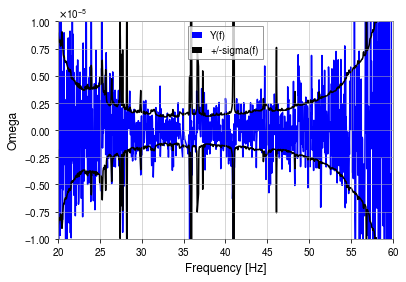

In [5]:
plt.plot(freqs_1,Y_f_1,color='blue',label='Y(f)')
plt.plot(freqs_1,sigma_f_1,color='black',label='+/-sigma(f)')
plt.plot(freqs_1,-sigma_f_1,color='black')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Omega')
plt.xlim(20,60)
plt.ylim(-1e-5,1e-5)
plt.legend()


In [6]:
fname_O2=download_file('https://dcc.ligo.org/public/0158/T1900058/003/Figure_1_Cf_spectra_O2.dat')
freqs_2,Y_f_2,sigma_f_2=np.loadtxt(fname_O2,unpack=True)
var_f_2=sigma_f_2**2

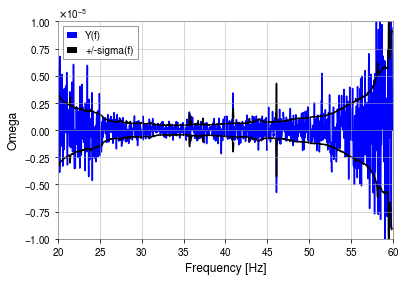

In [7]:
plt.plot(freqs_2,Y_f_2,color='blue',label='Y(f)')
plt.plot(freqs_2,sigma_f_2,color='black',label='+/-sigma(f)')
plt.plot(freqs_2,-sigma_f_2,color='black')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Omega')
plt.xlim(20,60)
plt.ylim(-1e-5,1e-5)
plt.legend()



In [8]:
cal_O1_H1 = 4.8 / 100
cal_O1_L1 = 5.4 / 100
cal_O2_H1 = 2.6 / 100
cal_O2_L1 = 3.85 / 100

cal_O1= np.sqrt(cal_O1_H1**2 + cal_O1_L1**2)
cal_O2= np.sqrt(cal_O2_H1**2 + cal_O2_L1**2)

#cal_O1=cal_O2

O1_data = Baseline('HL-O1',Y_f_1,var_f_1,freqs_1,calibration_epsilon=cal_O1)
O2_data = Baseline('HL-O2',Y_f_2,var_f_2,freqs_2,calibration_epsilon=cal_O2)

baselines=[O1_data,O2_data]


npoints=1024

# PE

In [9]:
label = 'GWB_powerlaw'
outdir = 'outdir'

Amin,Amax=1e-13,1e-5
fref=25

O2_UL_a0=3.5e-8
O2_UL_a2_3=3.0e-8
O2_UL_a3=5.1e-9
O2_UL_aMarg=3.4e-8

likelihood = PowerLawGWBLikelihood(baselines,fref=fref)

## alpha=0

22:24 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
22:24 bilby INFO    : Search parameters:
22:24 bilby INFO    :   A = LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
22:24 bilby INFO    :   alpha = 0
22:24 bilby INFO    : Single likelihood evaluation took 2.154e-03 s


0it [00:00, ?it/s]

22:24 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 1024, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 614, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc534434d10>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
22:24 bilby INFO    : Checkpoint every n_check_point = 300000
22:24 bilby INFO    : Using dynesty version 1.0.1
22:25 bilby INFO    : Using the bilby-implemented rwalk samp

3376it [01:51, 14.28it/s, bound:0 nc:32 ncall:27266 eff:12.4% logz-ratio=-0.30+/-0.03 dlogz:0.100>0.10] 

22:26 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



3377it [01:51, 30.26it/s, bound:0 nc:1 ncall:27273 eff:16.1% logz-ratio=-0.20+/-0.02 dlogz:0.000>0.10] 

22:26 bilby INFO    : Sampling time: 0:01:43.372673


22:26 bilby INFO    : Summary of results:
nsamples: 4401
log_noise_evidence: -26318.473
log_evidence: -26318.672 +/-  0.015
log_bayes_factor: -0.199 +/-  0.015



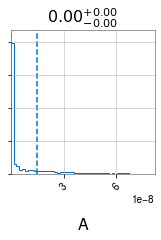

In [10]:
cleanup_dir(outdir)

alpha_fixed=0

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

95% UL = 3.408736e-08
95% UL from O2 paper = 3.500000e-08


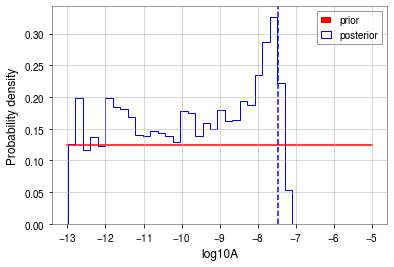

In [11]:
A=result.samples[:,0]


x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a0)
plt.legend()

## alpha=2/3

22:26 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
22:26 bilby INFO    : Search parameters:
22:26 bilby INFO    :   A = LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
22:26 bilby INFO    :   alpha = 0.6666666666666666
22:26 bilby INFO    : Single likelihood evaluation took 4.609e-03 s


0it [00:00, ?it/s]

22:26 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 1024, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 614, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc53431aa10>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
22:26 bilby INFO    : Checkpoint every n_check_point = 100000
22:26 bilby INFO    : Using dynesty version 1.0.1
22:27 bilby INFO    : Using the bilby-implemented rwalk samp

3578it [03:33,  4.85it/s, bound:0 nc:17 ncall:33593 eff:10.7% logz-ratio=-0.23+/-0.03 dlogz:0.100>0.10] 

22:30 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



3578it [03:34, 16.69it/s, bound:0 nc:1 ncall:33593 eff:13.7% logz-ratio=-0.13+/-0.02 dlogz:0.000>0.10] 

22:30 bilby INFO    : Sampling time: 0:03:21.434563


22:30 bilby INFO    : Summary of results:
nsamples: 4602
log_noise_evidence: -26318.473
log_evidence: -26318.604 +/-  0.022
log_bayes_factor: -0.131 +/-  0.022



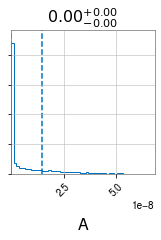

In [12]:
cleanup_dir(outdir)

alpha_fixed=2./3

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

95% UL = 2.985799e-08
95% UL from O2 paper = 3.000000e-08


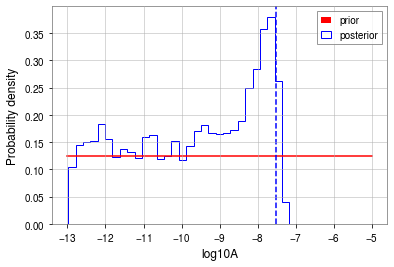

In [13]:
A=result.samples[:,0]

x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a2_3)
plt.legend()

## alpha=3

22:30 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
22:30 bilby INFO    : Search parameters:
22:30 bilby INFO    :   A = LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
22:30 bilby INFO    :   alpha = 3
22:30 bilby INFO    : Single likelihood evaluation took 4.448e-03 s


0it [00:00, ?it/s]

22:30 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 1024, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 614, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc534ee4d90>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
22:30 bilby INFO    : Checkpoint every n_check_point = 100000
22:30 bilby INFO    : Using dynesty version 1.0.1
22:30 bilby INFO    : Using the bilby-implemented rwalk samp

3658it [03:54,  6.13it/s, bound:0 nc:12 ncall:36273 eff:10.1% logz-ratio=-0.38+/-0.03 dlogz:0.100>0.10] 

22:34 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



3658it [03:55, 15.56it/s, bound:0 nc:1 ncall:36273 eff:12.9% logz-ratio=-0.29+/-0.03 dlogz:0.000>0.10] 

22:34 bilby INFO    : Sampling time: 0:03:42.282971


22:34 bilby INFO    : Summary of results:
nsamples: 4682
log_noise_evidence: -26318.473
log_evidence: -26318.760 +/-  0.027
log_bayes_factor: -0.287 +/-  0.027



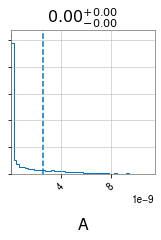

In [14]:
cleanup_dir(outdir)

alpha_fixed=3

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

95% UL = 4.871841e-09
95% UL from O2 paper = 5.100000e-09


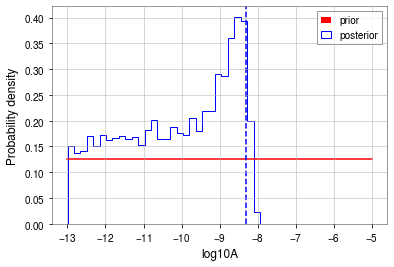

In [15]:
A=result.samples[:,0]

x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a3)
plt.legend()

## Marginalize over alpha with Gaussian prior

* 0 mean
* 3.5 standard deviation
* gives similar results to triangle prior

22:34 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
22:34 bilby INFO    : Search parameters:
22:34 bilby INFO    :   A = LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
22:34 bilby INFO    :   alpha = Gaussian(mu=0, sigma=3.5, name='alpha', latex_label='alpha', unit=None, boundary=None)
22:34 bilby INFO    : Single likelihood evaluation took 4.854e-03 s


0it [00:00, ?it/s]

22:34 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 1024, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 614, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc5364f4610>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
22:34 bilby INFO    : Checkpoint every n_check_point = 100000
22:34 bilby INFO    : Using dynesty version 1.0.1
22:34 bilby INFO    : Using the bilby-implemented rwalk samp

4121it [06:29,  3.12it/s, bound:37 nc:50 ncall:60078 eff:6.9% logz-ratio=-0.36+/-0.03 dlogz:0.100>0.10] 

22:40 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



4121it [06:30, 10.56it/s, bound:37 nc:1 ncall:60078 eff:8.6% logz-ratio=-0.28+/-0.03 dlogz:0.000>0.10] 



22:40 bilby INFO    : Sampling time: 0:06:16.509238
22:40 bilby INFO    : Summary of results:
nsamples: 5145
log_noise_evidence: -26318.473
log_evidence: -26318.758 +/-  0.033
log_bayes_factor: -0.285 +/-  0.033



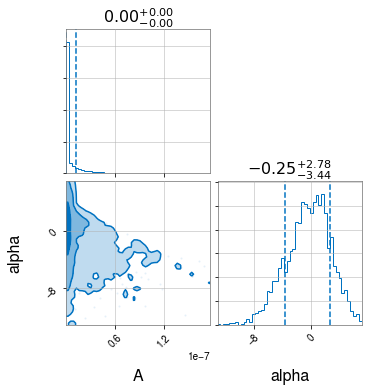

In [16]:
cleanup_dir(outdir)

alpha_mean=0
alpha_std=3.5

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Gaussian(alpha_mean,alpha_std, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [17]:
A=result.samples[:,0]
alpha=result.samples[:,1]

95% UL = 3.294058e-08
95% UL from O2 paper = 3.400000e-08


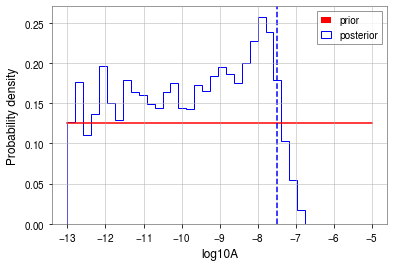

In [18]:
x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_aMarg)

plt.legend()

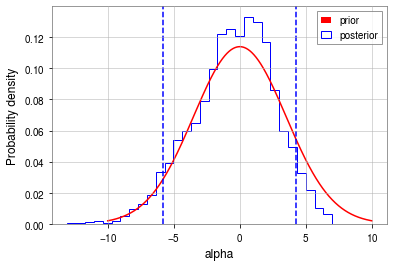

In [19]:
x=np.linspace(-10,10,1000)
prior=1/np.sqrt(2*np.pi*alpha_std**2) * np.exp(-0.5*(x/alpha_std)**2)
plt.plot(x,prior,color='red',label='prior')


plt.hist(alpha,bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')


plt.xlabel('alpha')
plt.ylabel('Probability density')
plt.legend()

# some sanity checks

In [20]:
baselines[0].calibration_epsilon

0.07224956747275378

In [21]:
baselines[1].calibration_epsilon

0.04645696933722647